In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

#Phase 1 EDA & Hiểu Data

Phase 1 - Load Data & Raw Plot

Đang tải nhãn (labels) từ NAB GitHub...
Đã map THÀNH CÔNG nhãn gốc (True Anomalies) vào dữ liệu!


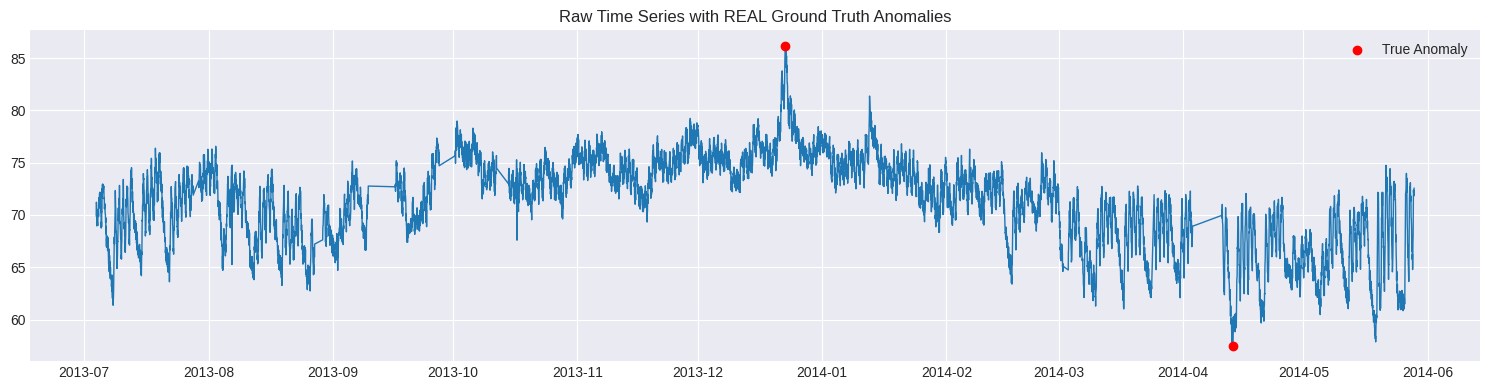

In [28]:
import urllib.request
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/AIOps/ambient_temperature_system_failure.csv'
df = pd.read_csv(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

url = "https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_labels.json"
print("Đang tải nhãn (labels) từ NAB GitHub...")

try:
    response = urllib.request.urlopen(url)
    labels_json = json.loads(response.read().decode())

    # Key chuẩn của file trong database NAB
    file_key = 'realKnownCause/ambient_temperature_system_failure.csv'
    df['is_anomaly'] = 0

    if file_key in labels_json:
        anomaly_timestamps = labels_json[file_key]
        for ts in anomaly_timestamps:
            # Map timestamp anomaly vào thời điểm gần nhất trong file data
            nearest_idx = df.index.get_indexer([pd.to_datetime(ts)], method='nearest')[0]
            df.iloc[nearest_idx, df.columns.get_loc('is_anomaly')] = 1
        print("Đã map THÀNH CÔNG nhãn gốc (True Anomalies) vào dữ liệu!")
    else:
        print("Không tìm thấy key. Dùng nhãn giả.")
        # Fallback dummy
        np.random.seed(42)
        anomaly_indices = np.random.choice(df.index, size=int(len(df)*0.02), replace=False)
        df.loc[anomaly_indices, 'is_anomaly'] = 1

except Exception as e:
    print(f"Lỗi mạng không lấy được nhãn thật: {e}. Đang dùng nhãn giả.")
    # Fallback dummy
    df['is_anomaly'] = 0
    np.random.seed(42)
    anomaly_indices = np.random.choice(df.index, size=int(len(df)*0.02), replace=False)
    df.loc[anomaly_indices, 'is_anomaly'] = 1

plt.figure(figsize=(15, 4))
plt.plot(df.index, df['value'], color='#1f77b4', linewidth=1)
anomalies_true = df[df['is_anomaly'] == 1]
plt.scatter(anomalies_true.index, anomalies_true['value'], color='red', label='True Anomaly', zorder=5)
plt.title('Raw Time Series with REAL Ground Truth Anomalies')
plt.legend()
plt.tight_layout()
plt.show()

Phase 1 - Basic Stats, Skewness & Seasonality (ACF)

--- BASIC STATS ---
Mean: 71.24 | Std: 4.25 | Min: 57.46 | Max: 86.22
Skewness: -0.39
Dữ liệu phân phối chuẩn (Gaussian).


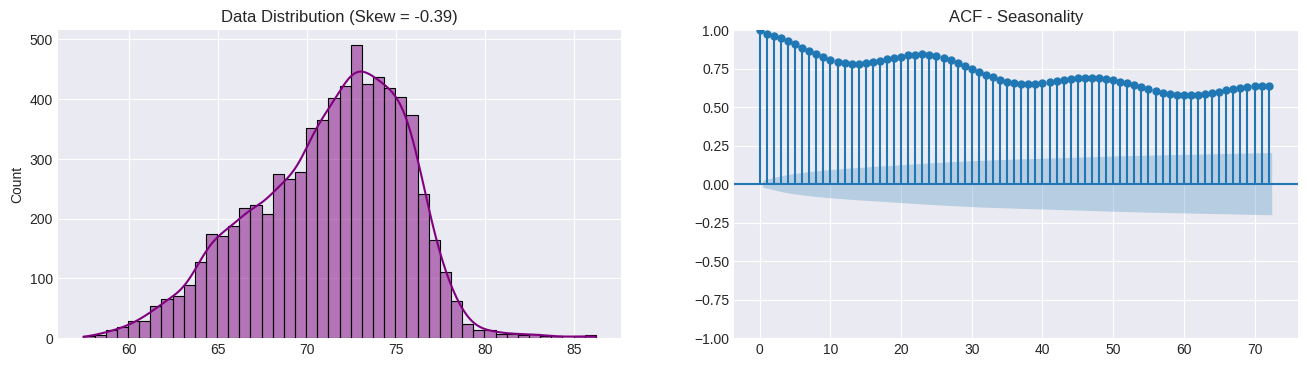

In [29]:
data = df['value'].dropna().values

print("--- BASIC STATS ---")
print(f"Mean: {data.mean():.2f} | Std: {data.std():.2f} | Min: {data.min():.2f} | Max: {data.max():.2f}")

skewness = stats.skew(data)
print(f"Skewness: {skewness:.2f}")
if abs(skewness) < 0.5:
    print("Dữ liệu phân phối chuẩn (Gaussian).")
elif abs(skewness) < 1.0:
    print("Dữ liệu lệch vừa (Moderate skew).")
else:
    print("Dữ liệu lệch nặng (Heavily skewed). Cân nhắc IQR hoặc Log Transform.")

# Phân phối
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(data, kde=True, ax=ax[0], color='purple')
ax[0].set_title(f'Data Distribution (Skew = {skewness:.2f})')

# ACF để tìm chu kỳ (để lags 72 vì nghi ngờ tính mùa vụ theo ngày)
plot_acf(data, lags=72, ax=ax[1])
ax[1].set_title('ACF - Seasonality')
plt.show()

#Phase 2: Implement 2 Detectors

Phase 2 - Feature Engineering cho ML

In [30]:
def build_features(series, window=24):
    """Tạo bảng features có context để feed vào Isolation Forest"""
    s = pd.Series(series)
    features = pd.DataFrame({
        'value': s,
        'rolling_mean_1h': s.rolling(window, min_periods=1).mean(),
        'rolling_std_1h': s.rolling(window, min_periods=1).std().fillna(0),
        'rate_of_change': s.diff().fillna(0),
        'lag_1': s.shift(1).fillna(method='bfill')
    })
    return features

# Tạo feature table cho toàn bộ dataframe
X_features = build_features(df['value'])
print("Feature table shape:", X_features.shape)
X_features.head()

Feature table shape: (7267, 5)


,value,rolling_mean_1h,rolling_std_1h,rate_of_change,lag_1
timestamp,,,,,
2013-07-04 00:00:00,69.880835,69.880835,0.000000,0.000000,69.880835
2013-07-04 01:00:00,71.220227,70.550531,0.947093,1.339392,69.880835
2013-07-04 02:00:00,70.877805,70.659622,0.695842,-0.342422,71.220227
2013-07-04 03:00:00,68.959400,70.234567,1.022490,-1.918405,70.877805
2013-07-04 04:00:00,69.283551,70.044364,0.982344,0.324151,68.959400


Phase 2 - Code 2 Detectors (Statistical & ML)

In [31]:
from statsmodels.tsa.seasonal import STL

# DETECTOR 1: STL + 3σ (STATISTICAL)
# Chọn STL vì dữ liệu có tính mùa vụ (nhiệt độ ngày/đêm).
# Period = 24 vì dữ liệu là 1 giờ/điểm, 1 ngày = 24 điểm.
def detect_stl(series, period=24, threshold=3.0):
    stl = STL(series, period=period, robust=True)
    result = stl.fit()
    residual = result.resid
    resid_mean = np.mean(residual)
    resid_std = np.std(residual)

    anomalies = np.abs(residual - resid_mean) > threshold * resid_std
    return anomalies.astype(int)

df['pred_stat'] = detect_stl(df['value'], period=24, threshold=3.0)


# DETECTOR 2: ISOLATION FOREST (ML)
# Contamination để thấp (0.01) vì số chấm đỏ thực tế rất ít
clf_if = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
clf_if.fit(X_features)

# Predict: IF trả về -1 (anomaly) và 1 (normal). Ta map về 1 và 0 cho giống ground truth.
preds = clf_if.predict(X_features)
df['pred_ml'] = np.where(preds == -1, 1, 0)

print("Đã chạy xong cả 2 Detectors: STL và Isolation Forest!")

Đã chạy xong cả 2 Detectors: STL và Isolation Forest!


Phase 2 - Đánh giá, Lập bảng So sánh & Biểu đồ

--- BẢNG ĐÁNH GIÁ MÔ HÌNH ---


,Detector,Precision,Recall,F1,False Alarms
0,STL + 3σ,0.005495,0.5,0.010870,181
1,Isolation Forest,0.027397,1.0,0.053333,71


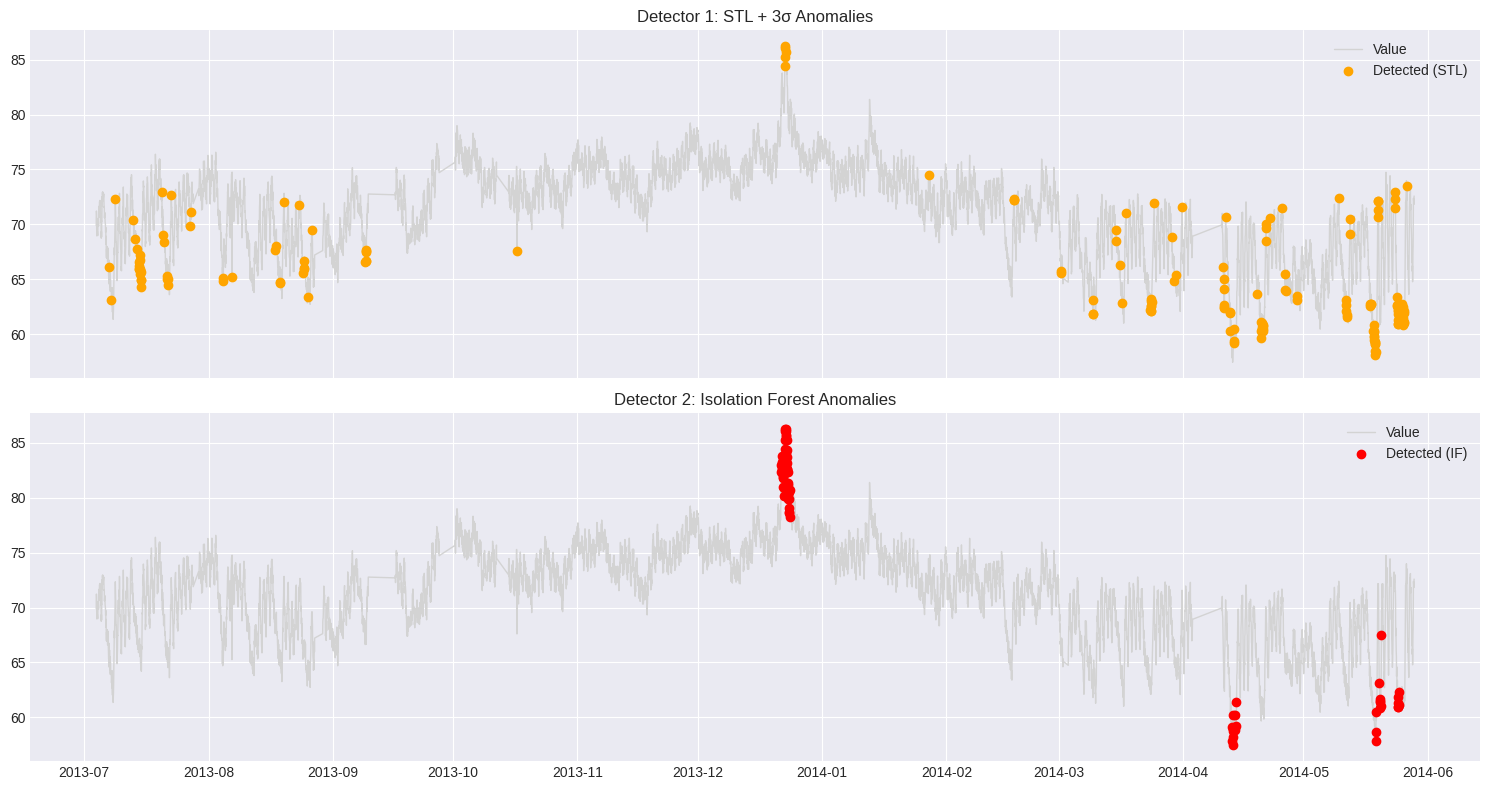

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Hàm tính metrics đánh giá
def evaluate_detector(y_true, y_pred, name):
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    fp = np.sum((y_pred == 1) & (y_true == 0))
    return {'Detector': name, 'Precision': p, 'Recall': r, 'F1': f1, 'False Alarms': fp}

# Tính toán điểm cho STL và Isolation Forest
res_stat = evaluate_detector(df['is_anomaly'], df['pred_stat'], 'STL + 3σ')
res_ml = evaluate_detector(df['is_anomaly'], df['pred_ml'], 'Isolation Forest')

results_df = pd.DataFrame([res_stat, res_ml])
print("--- BẢNG ĐÁNH GIÁ MÔ HÌNH ---")
display(results_df)

# 2. Plot biểu đồ so sánh 2 subplot
fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Statistical(STL)
ax[0].plot(df.index, df['value'], color='lightgray', label='Value', linewidth=1)
anoms_stat = df[df['pred_stat'] == 1]
ax[0].scatter(anoms_stat.index, anoms_stat['value'], color='orange', label='Detected (STL)', zorder=5)
ax[0].set_title('Detector 1: STL + 3σ Anomalies')
ax[0].legend()

# ML(IF)
ax[1].plot(df.index, df['value'], color='lightgray', label='Value', linewidth=1)
anoms_ml = df[df['pred_ml'] == 1]
ax[1].scatter(anoms_ml.index, anoms_ml['value'], color='red', label='Detected (IF)', zorder=5)
ax[1].set_title('Detector 2: Isolation Forest Anomalies')
ax[1].legend()

plt.tight_layout()
plt.show()

#Phase 3: So Sánh & Reflection

Cell 7: Phase 3 - Tuning Contamination & Export Model

In [33]:
# Thử nghiệm các ngưỡng contamination khác nhau cho IF
print("--- TUNE CONTAMINATION (ISOLATION FOREST) ---")
tune_results = []
for contam in [0.01, 0.02, 0.05]:
    clf_tune = IsolationForest(n_estimators=200, contamination=contam, random_state=42)
    clf_tune.fit(X_features)
    preds_tune = np.where(clf_tune.predict(X_features) == -1, 1, 0)

    p = precision_score(df['is_anomaly'], preds_tune, zero_division=0)
    r = recall_score(df['is_anomaly'], preds_tune, zero_division=0)
    f1 = f1_score(df['is_anomaly'], preds_tune, zero_division=0)
    tune_results.append({'Contamination': contam, 'Precision': p, 'Recall': r, 'F1': f1})

tune_df = pd.DataFrame(tune_results)
display(tune_df)

# Lưu model Isolation Forest
model_filename = 'isolation_forest_model.pkl'
joblib.dump(clf_if, model_filename)
print(f"Đã lưu model thành file: {model_filename}")

--- TUNE CONTAMINATION (ISOLATION FOREST) ---


,Contamination,Precision,Recall,F1
0,0.01,0.027397,1.0,0.053333
1,0.02,0.013699,1.0,0.027027
2,0.05,0.005495,1.0,0.010929


Đã lưu model thành file: isolation_forest_model.pkl
